# Laboratorio 1




## Exploración de datos

El primer paso en el ciclo en la elaboración de un modelo de machine learning es la exploración de los datos con el fin 

de explorar el conjunto de información compartida y determinar problemas de calidad. El primer paso es cargar el csv con los datos de interés en

un datframe de Pandas.


In [3]:
import pandas as pd
import matplotlib.pyplot as plt
df = pd.read_csv("Datos lab 1.csv")
df.head()



,fecha,presion_media,presion_min,presion_max,presion_desv,humedad_media,humedad_min,humedad_max,humedad_desv,viento_media,...,viento_norte,viento_este,direccion_viento,registros_del_dia,anio,dia_del_anio,estacion_anio,mes,sector_viento,temp_max_manana
0,2009-01-01,999.1456,996.50,1000.87,1.3993,0.910860,0.875000,94.8,1.7650,0.7786,...,-0.3618,-0.0223,183.5308,143.0,2009.0,1.0,invierno,January,S,-2.12
1,2009-01-02,999.6006,997.93,1002.65,1.5039,0.920868,86.600000,96.3,2.7588,1.4195,...,0.4267,0.3689,40.8436,144.0,2009.0,2.0,invierno,JULY,NE,-0.82
2,2009-01-03,998.5486,993.05,1002.49,3.1304,76.458100,48.390000,93.9,15.1796,1.2509,...,-0.6993,-0.5268,216.9916,144.0,2009.0,3.0,invierno,January,SO,-0.63
3,2009-01-04,988.5107,985.12,992.93,2.3223,89.417400,97.946704,NaN,4.4904,1.7204,...,-1.1268,-1.0413,222.7419,144.0,2009.0,4.0,invierno,JANUARY,SO,-1.44
4,2009-01-05,990.4057,NaN,997.54,4.2315,86.260400,74.600000,93.2,5.3922,3.8003,...,2.6275,0.2874,6.2418,NaN,2009.0,5.0,East,January,N,-10.88


Una vez cargados los datos en el dataframe podemos explorar su contenido para entender su estructura general , sus tipos de datos y explorar los 

valores nulos y duplicados que puedan aparecer.

In [4]:
df.info()
df.shape

<class 'pandas.DataFrame'>
RangeIndex: 2576 entries, 0 to 2575
Data columns (total 27 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   fecha              2504 non-null   str    
 1   presion_media      2501 non-null   float64
 2   presion_min        2502 non-null   float64
 3   presion_max        2512 non-null   float64
 4   presion_desv       2496 non-null   float64
 5   humedad_media      2502 non-null   float64
 6   humedad_min        2496 non-null   float64
 7   humedad_max        2490 non-null   float64
 8   humedad_desv       2515 non-null   float64
 9   viento_media       2490 non-null   float64
 10  viento_min         2485 non-null   float64
 11  viento_max         2495 non-null   float64
 12  viento_desv        2504 non-null   float64
 13  rafaga_media       2498 non-null   float64
 14  rafaga_min         2504 non-null   float64
 15  rafaga_max         2503 non-null   float64
 16  rafaga_desv        2497 non-null   

(2576, 27)


### Tipos estadisticos de las columnas

Ahora que tenemos la información de cada columna es posible obtener sus tipos estadisticos.

| Columna | Significado | Tipo estadístico |
|---|---|---|
| `fecha` | Fecha del registro (un día) | Cualitativa nominal (temporal) |
| `presion_media` | Presión atmosférica media del día | Cuantitativa continua |
| `presion_min` | Presión atmosférica mínima del día | Cuantitativa continua |
| `presion_max` | Presión atmosférica máxima del día | Cuantitativa continua |
| `presion_desv` | Desviación estándar de la presión del día | Cuantitativa continua |
| `humedad_media` | Humedad relativa media del día | Cuantitativa continua |
| `humedad_min` | Humedad relativa mínima del día | Cuantitativa continua |
| `humedad_max` | Humedad relativa máxima del día | Cuantitativa continua |
| `humedad_desv` | Desviación estándar de la humedad del día | Cuantitativa continua |
| `viento_media` | Velocidad media del viento del día | Cuantitativa continua |
| `viento_min` | Velocidad mínima del viento del día | Cuantitativa continua |
| `viento_max` | Velocidad máxima del viento del día | Cuantitativa continua |
| `viento_desv` | Desviación estándar de la velocidad del viento | Cuantitativa continua |
| `rafaga_media` | Velocidad media de ráfagas del día | Cuantitativa continua |
| `rafaga_min` | Velocidad mínima de ráfagas del día | Cuantitativa continua |
| `rafaga_max` | Velocidad máxima de ráfagas del día | Cuantitativa continua |
| `rafaga_desv` | Desviación estándar de ráfagas del día | Cuantitativa continua |
| `viento_norte` | Componente norte-sur del viento (ya transformado) | Cuantitativa continua |
| `viento_este` | Componente este-oeste del viento (ya transformado) | Cuantitativa continua |
| `direccion_viento` | Dirección del viento en grados (0-360°) | Cuantitativa continua (circular) |
| `registros_del_dia` | Cantidad de mediciones tomadas ese día | Cuantitativa discreta |
| `anio` | Año del registro | Cualitativa nominal |
| `dia_del_anio` | Día del año (1-366) | Cuantitativa discreta |
| `estacion_anio` | Estación del año | Cualitativa nominal |
| `mes` | Mes del año | Cualitativa ordinal |
| `sector_viento` | Sector/dirección cardinal del viento | Cualitativa nominal |
| `temp_max_manana` | Temperatura máxima (variable objetivo) | Cuantitativa continua |




### Evaluación de las 4 dimensiones de calidad de datos.

Una vez que se han identificado los tipos estadisticos de las columnas es necesario explorar las 4 dimensiones de calidad de datos, comenzando 

por la completitud, en la cual se verifica cuantas columnas tienen datos nulos para posteriormente completarlos. Posteriormente hay que explorar 

si existen filas identicas y revisar si hay algún identificador único. Luego , nos enfocamos en la consistencia en busqueda de formatos 

inconsistentes en columnas tipo texto. Y por último la validez de los datos, buscando detectar valores fuera de rango.

In [5]:
df.isnull().sum()


fecha                72
presion_media        75
presion_min          74
presion_max          64
presion_desv         80
humedad_media        74
humedad_min          80
humedad_max          86
humedad_desv         61
viento_media         86
viento_min           91
viento_max           81
viento_desv          72
rafaga_media         78
rafaga_min           72
rafaga_max           73
rafaga_desv          79
viento_norte         80
viento_este          64
direccion_viento     79
registros_del_dia    77
anio                 86
dia_del_anio         68
estacion_anio        88
mes                  88
sector_viento        71
temp_max_manana      95
dtype: int64

Se puede evidenciar gracias al codigo anterior que existen una gran cantidad de valores repetidos en cada columna, aproximadamente entre 60 y 95 

por columna, lo cual afecta en gran medida la unicidad del conjunto de datos.

In [6]:
df.duplicated().sum()
print("Duplicados por fecha:", df['fecha'].duplicated().sum())

Duplicados por fecha: 89


Además de las 4 filas idénticas detectadas con duplicated(), se identificaron 89 fechas repetidas pero con valores ligeramente distintos entre 

si, loq ue representa un riesgo enrome de inconsistencia y de posible fuga de datos.

In [7]:
df.describe()

,presion_media,presion_min,presion_max,presion_desv,humedad_media,humedad_min,humedad_max,humedad_desv,viento_media,viento_min,...,rafaga_min,rafaga_max,rafaga_desv,viento_norte,viento_este,direccion_viento,registros_del_dia,anio,dia_del_anio,temp_max_manana
count,2501.000000,2502.000000,2512.000000,2496.000000,2502.000000,2496.000000,2490.000000,2515.000000,2490.000000,2485.000000,...,2504.000000,2503.000000,2497.000000,2496.000000,2512.000000,2497.000000,2499.000000,2490.000000,2508.000000,2481.000000
mean,1010.494271,986.684409,991.704244,1.752041,52.413586,45.094067,90.236582,10.606821,3.814103,1.417799,...,-2.639322,6.946058,-5.763253,-1.128463,-0.410159,172.104573,144.090836,2011.995582,182.690989,13.863309
std,435.334494,8.927138,7.726906,1.215931,35.975384,30.196163,10.647237,5.481338,3.307402,3.960650,...,199.861693,3.237379,75.258134,25.065084,1.147218,86.102348,4.107365,1.999694,105.529469,9.296199
min,948.996000,913.600000,951.940000,0.226900,0.004663,0.237700,27.020000,0.000000,0.000000,0.000000,...,-9999.000000,0.000000,-232.260000,-1250.463300,-3.718500,0.000000,90.000000,2009.000000,1.000000,-15.230000
25%,984.287800,981.371333,987.070000,0.899050,0.869060,1.011790,88.025000,6.082100,1.655350,0.230000,...,0.440000,4.803198,1.002100,-1.640625,-1.236475,91.303500,144.000000,2010.000000,91.000000,7.310000
50%,989.452800,987.070000,991.935000,1.444550,68.558100,49.670000,93.300000,10.199800,2.463400,0.440000,...,0.660000,6.690000,1.461100,-0.564300,-0.356000,199.568500,144.000000,2012.000000,182.500000,14.310000
75%,994.469000,992.567500,996.782500,2.254800,80.562600,67.665000,96.600000,14.722200,4.880505,0.960000,...,1.120000,8.850000,2.008800,0.241525,0.316275,227.101700,144.000000,2014.000000,274.250000,20.460000
max,9939.918000,1012.320198,1013.940000,12.397500,100.000000,103.311405,100.000000,26.341600,24.753600,45.184956,...,19.895916,23.500000,3471.027800,4.809900,4.713900,359.796700,287.000000,2015.000000,366.000000,63.050000


Con el método describe somos capaces de ver información relevante de cada una de las 27 columnas en busqueda de valores atipicos o fuera de rango.

Tal como se puede visualizar, hay columnas que cuentas con datos muy fuera de rango, como los componentes del viento y las rafagas maximas y 

minimas los cuales a pesar de estar medidos en metros sobre segundos, presentan datos negativos lo 1ue respresenta que el dato es nulo o una 

medición incoherente. Por otro lado, la variable objetivo tiene valores extremos incoherentes , puestoa que arroja temperaturas de 63 grados, lo 

cual viene a ser poco realista. De igual manera la presión media arroja valores máximos exagerados como 9939 lo cual es físicamnete imposible 

teniendo en cuenta que la presíon atmosferica normal ronda entre los 950 y 1050 mbar.





 Dependiendo de la cantidad de filas que  tengan esta medición, se puede considerar como un error importante que afecte la 

validez de los datos. Posteriormente en preparación se va indagar con mayor profundidad con el fin de determinar una solución.

In [8]:
columnas_texto = ['estacion_anio', 'mes', 'sector_viento']

for col in columnas_texto:
    print(f"\n{'='*50}")
    print(f"Columna: {col}")
    print(f"{'='*50}")
    print(f"Valores únicos: {df[col].nunique()}")
    print(f"Nulos: {df[col].isnull().sum()}")
    print(f"\nConteo de valores:")
    print(df[col].value_counts(dropna=False))


Columna: estacion_anio
Valores únicos: 28
Nulos: 88

Conteo de valores:
estacion_anio
primavera               517
invierno                511
otono                   500
verano                  487
NaN                      88
Inverano                 71
Estacion_Desconocida     63
VERANO_INVIERNO          60
East                     48
VERANO                   19
autumn                   18
primaveraa               17
berano                   17
fall                     15
winter                   15
verno                    14
Otoño                    12
otoño                    11
invernio                 11
Primavera                10
PRIMAVERA                10
invierno                  9
INVIERNO                  9
Verano                    9
Invierno                  9
OTONO                     8
primav                    6
spring                    6
summer                    6
Name: count, dtype: int64

Columna: mes
Valores únicos: 61
Nulos: 88

Conteo de valores:
mes
May     

En el codigo anterior es posible darse cuenta que muchos de los duplicados del codigo pueden ser casusados por la falta de normalización en los 

campos de texto puesto a que hay una gran cantidad de valores únicos para expresar un mismo valor. Especificamente hay 28 valores únicos en la 

columna estaciones a pesar de que no existe esa cantidad, similar pasa con la columna de meses y sector viento. Posteriormente se debe normalizar 

cada una de estas columnas y de este modo se espera eliminar duplicados y disminuir el ruido.

In [9]:
df['fecha'].dropna().apply(lambda x: len(x)).value_counts()

fecha
10    2504
Name: count, dtype: int64

Por suerte se puede concluir que todos los datos de la columna fecha estan normalizados y tiene n la misma cantidad de carácteres. Los datos 

restantes corresponden a valores nulos que se deben tratar en la parte de preparación.

### Visualización de los datos.

Es de vital importancia la vizualización de ciertos datos dentro del dataset mediante herramientas como boxplots,histogramas, scatterplots y gráficos de 

línea con el fin de identificar outliers, intuir relaciones entre variables e identificar tendencias y estacionalidad.

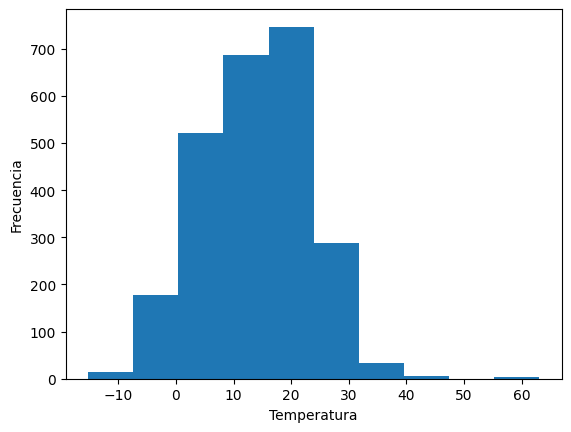

In [10]:

datos = df['temp_max_manana']

plt.hist(datos)
plt.xlabel("Temperatura")
plt.ylabel("Frecuencia")

plt.show()


A partir del histograma se puede conlcluir que hay un fuerte sesgo hacia la derecha (asimetria positiva), puesto a que la mayoría de los datos se 

concentran entre 0 y 30 grados , con el pico más alto alrededor de 15 y 20 grados, además podemos ver valores extremos que lo más seguro es que 

representen errores de medición ya que un máximo de 63 grados es fisicamente imposible para Jena, Alemania. Las frecuencias que aparecen luego de 

los 45 grados pueden tratarse de errores de captura de datos o psoiblemente se mezclaron unidades.

El siguiente paso ahora es buscar las variables que presenten una mayor correlación con nuestra columna objetivo. Con el fin de agilizar la 

búsqueda y sacar concluisiones mediante datos concretos hare uso de una matriz de correlación (heatmap), propia de la libreria seaborn , la cual 

me dará un vistazo de las variables que más se relacionan con temperatura.

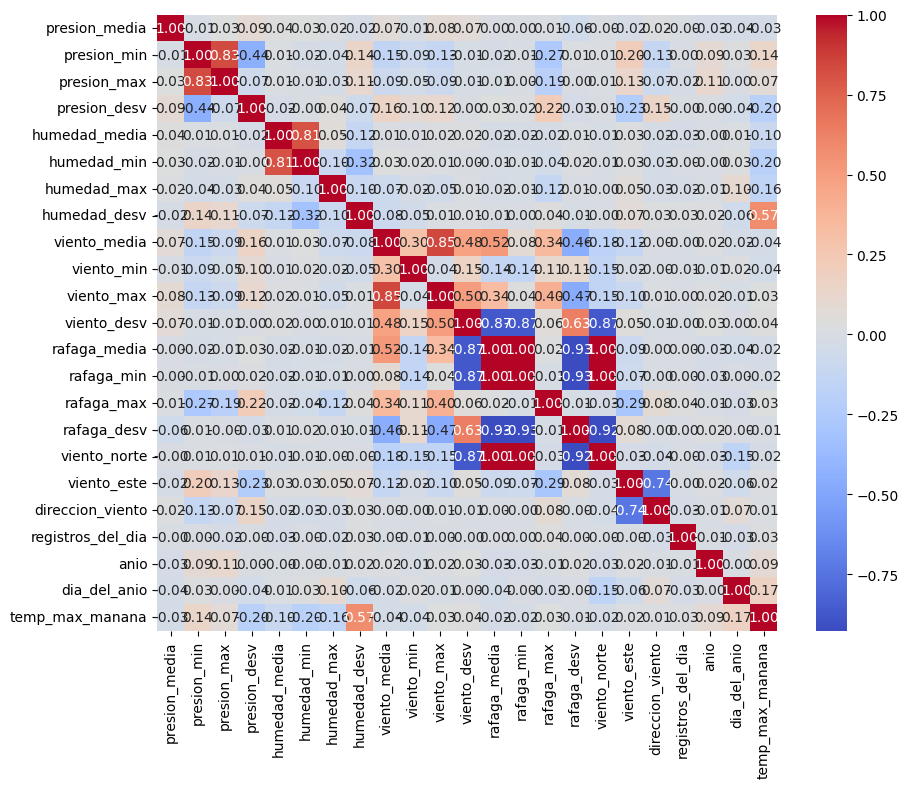

In [11]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10,8))
sns.heatmap(df.corr(numeric_only=True), annot= True, cmap="coolwarm", fmt=".2f")
plt.show()

Gracias al mapa de calor podemos evidenciar que existe en varias de las variables númericas una muy baja correlación con nuestra variable 

objetivo. En especial las que están relacionadas con viento y rafagas ya que rondan entre 0.1 y 0.04 de correlación, lo que nos puede ayudar a 

descartar estas variables para predecir la temperatura del día siguiente. Sin embargo, la desviación típica de la humedad ha demostrado tener una 

correlación mediana-fuerte con la variable temperatura, lo cual la puede definir como una buena candidata para el modelo de regresión lineal.

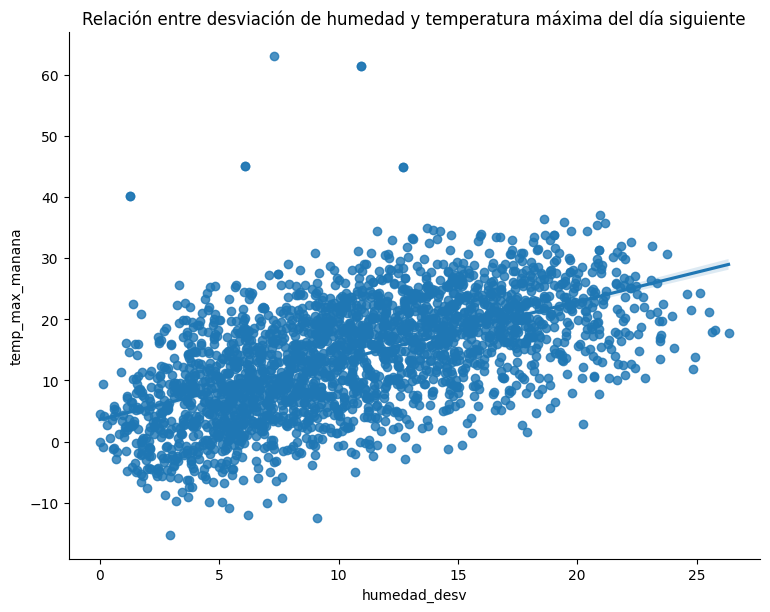

In [12]:

sns.lmplot(x='humedad_desv', y='temp_max_manana', data=df, height=6, aspect=1.3)
plt.title("Relación entre desviación de humedad y temperatura máxima del día siguiente")
plt.show()

El scatterplot entre humedad_desv y temperatura_max_manana nos confirma una relación lineal positiva moderada en la mayoría de los datos, y de 

paso nos confirma la existencia de 4-5 valores atípicos (temperaturas >= 40), los cuales están completamente aislados de la nube , lo que 

respalda la idea de tratarlos como errores en la etapa de preparación.

### Conclusión Exploración

En resumen, la exploración reveló problemas en las 4 dimensiones de calidad. Por el lado de completitud evidenció la existencia de entre 60 a 95 

valores nulos por columna. En unicidad hubo 4 filas duplicadas. Existian una gran cantidad de datos inconsistentes dentro de las variables de 

estacion_anio, mes, sector_viento, con formatos no normalizados. Y por el lado de la validez existen valores fisicamente imposibles en 

temp_max_manana, presion_media, viento_norte y componentes de viento negativos. La busqueda de soluciones a estos errores guiarán el desarrollo 

de la siguiente etapa.

## Preparación de los datos.

### Eliminación de duplicados.

El primer paso en la preparación es la eliminación de las 4 filas duplicadas que se identificaron anteriormente.

In [13]:
print("Filas antes de eliminar duplicados:", df.shape[0])
df = df.drop_duplicates()
print("Filas después de eliminar duplicados:", df.shape[0])

Filas antes de eliminar duplicados: 2576
Filas después de eliminar duplicados: 2572


Ademáas de las 4 filas duplicadas es de vital importancia encargarse de las fechas duplicadas con ligeros cambios en las filas, como se

 identificó anteriormente.

In [14]:
# Se eliminan las fechas repetidas, conservando una fecha por fila
df = df.sort_values('fecha').drop_duplicates(subset='fecha', keep='first')

# Al ser un identificador unico , elimino tpda fila con una fecha nula
df = df.dropna(subset=['fecha'])

# Ordeno el data set tomando como indice la fecha 
df = df.sort_values('fecha').reset_index(drop=True)

# Elimino aquellas filas con una variable objetivo nula para evitar inventar el valor que trato de predecir
df = df.dropna(subset=['temp_max_manana'])

df.shape[0]

2393

Se opto por eliminar las fechas duplicadas ya que según el diccionario de datos cada fila del dataset representa la agregación diaria de

mediciones, por lo que se espera un registro por día. Al encontrarse 89 fechas con más de una fila asociada, algunas con valores en la fila 

identicos y otras con valores ligeramente distintos entre sí, se determinó que esto constituye un error de calidad en la dimensión de unicidad. 

Asimismo, mantener múltiples filas para una misma fecha rompe el supuesto de independencia entre observaciones que requiere la regresión lineal.



Por otro lado, se decidió eliminar los nulos de la variable objetivo ya que esto implica inventar la etiqueta que el modelo está tratando de 

predecir. Esto ocasiona que el modelo se entrene parcialmente con valores sinteticos que no fueron medidos realmente, lo que puede ocasionar un 

sesgo.

### Tratamiento de nulos.


Una vez eliminados los duplicados el siguiente paso es el tratamiento de los valores nulos.


In [15]:
# Se pasa el formato de fecha de cadena de texto a Date Time.

df['fecha'] = pd.to_datetime(df['fecha'], format='%Y-%m-%d')

# Identifico las columnas de tipo numerica.

columnas_numericas = df.select_dtypes(include='number').columns

# Relleno los nulos.

df[columnas_numericas] = df[columnas_numericas].interpolate(method='linear', limit_direction='both')

# Verificación 

print(df[columnas_numericas].isnull().sum())
df.shape[0]

presion_media        0
presion_min          0
presion_max          0
presion_desv         0
humedad_media        0
humedad_min          0
humedad_max          0
humedad_desv         0
viento_media         0
viento_min           0
viento_max           0
viento_desv          0
rafaga_media         0
rafaga_min           0
rafaga_max           0
rafaga_desv          0
viento_norte         0
viento_este          0
direccion_viento     0
registros_del_dia    0
anio                 0
dia_del_anio         0
temp_max_manana      0
dtype: int64


2393

En el codigo anterior cambio el formato predeterminado de fecha dado por el programa a uno más adecuado (Date time) y lo utilizo como idice del 

data set para ordenar los valores. Despúes tras identificar las columnas númericas utilizo la técnica de interpolación para rellenar los campos 

nulos calculando un punto intermedio entre el valor anterior y el siguiente de esa misma columna. La razón por la que utilicé este método y no 

uno que involucre a la media o la mediana es porque son datos meteorológicos diarios que por lo general no varian mucho de un día para otro , lo 

que indica que un día faltante puede parecerse mucho al día anterior y al siguiente. En caso de que hubiera utilizado la media global de 8 años 

para rellenar los datos, estaría ignorando por completo el contexto temporal e incluiría un dato poco realista.

### Normalización de formatos.

Uno de los problemás más criticos que pudimos evidenciar en la sección de exploración fue la falta de normalización de los campos de texto, ya 

que existen datos incoherentes o que significan los mismo pero expresado en diferentes maneras. Esto puede ocasionar una gran cantidad de ruido 

estadistico.

In [16]:
mask_min = df['humedad_min'] < 1
df.loc[mask_min, 'humedad_min'] = df.loc[mask_min, 'humedad_min'] * 100

In [17]:
# Paso 1: normalizar formato básico (minúsculas + quitar espacios) antes de mapear
for col in ['estacion_anio', 'mes', 'sector_viento']:
    df[col] = df[col].str.strip().str.lower()

# Paso 2: mapeo de estacion_anio
mapa_estacion = {
    'invierno': 'invierno', 'invernio': 'invierno', 'winter': 'invierno',
    'primavera': 'primavera', 'primav': 'primavera', 'primaveraa': 'primavera', 'spring': 'primavera',
    'verano': 'verano', 'berano': 'verano', 'verno': 'verano', 'summer': 'verano',
    'otoño': 'otoño', 'otono': 'otoño', 'fall': 'otoño', 'autumn': 'otoño',
    # valores inválidos / ambiguos -> se marcan como nulos
    'east': None, 'estacion_desconocida': None, 'inverano': None, 'verano_invierno': None
}
df['estacion_anio'] = df['estacion_anio'].map(mapa_estacion)

# Paso 3: mapeo de mes
mapa_mes = {
    'enero': 'enero', 'jan': 'enero', 'january': 'enero',
    'febrero': 'febrero', 'feb': 'febrero', 'february': 'febrero',
    'marzo': 'marzo', 'mar': 'marzo', 'march': 'marzo',
    'abril': 'abril', 'apr': 'abril', 'april': 'abril',
    'mayo': 'mayo', 'may': 'mayo',
    'junio': 'junio', 'jun': 'junio', 'june': 'junio',
    'julio': 'julio', 'jul': 'julio', 'july': 'julio',
    'agosto': 'agosto', 'aug': 'agosto', 'august': 'agosto',
    'septiembre': 'septiembre', 'sep': 'septiembre', 'sept': 'septiembre', 'september': 'septiembre',
    'octubre': 'octubre', 'oct': 'octubre', 'october': 'octubre',
    'noviembre': 'noviembre', 'nov': 'noviembre', 'november': 'noviembre',
    'diciembre': 'diciembre', 'dec': 'diciembre', 'december': 'diciembre'
}
df['mes'] = df['mes'].map(mapa_mes)

# Paso 4: mapeo de sector_viento
mapa_viento = {
    'n': 'norte', 'norte': 'norte', 'north': 'norte',
    's': 'sur', 'sur': 'sur', 'south': 'sur',
    'e': 'este', 'este': 'este', 'east': 'este',
    'o': 'oeste', 'oeste': 'oeste', 'west': 'oeste',
    'ne': 'noreste', 'noreste': 'noreste', 'northeast': 'noreste',
    'no': 'noroeste', 'noroeste': 'noroeste', 'northwest': 'noroeste',
    'se': 'sureste', 'sureste': 'sureste', 'southeast': 'sureste',
    'so': 'suroeste', 'suroeste': 'suroeste', 'southwest': 'suroeste'
}
df['sector_viento'] = df['sector_viento'].map(mapa_viento)

# Verificación final
for col in ['estacion_anio', 'mes', 'sector_viento']:
    print(f"\n{col}: {df[col].nunique()} categorías, {df[col].isnull().sum()} nulos")
    print(df[col].value_counts())


estacion_anio: 4 categorías, 305 nulos
estacion_anio
primavera    537
invierno     529
otoño        519
verano       503
Name: count, dtype: int64

mes: 12 categorías, 86 nulos
mes
septiembre    215
enero         209
marzo         202
julio         198
noviembre     196
diciembre     195
agosto        191
mayo          188
octubre       183
febrero       183
junio         179
abril         168
Name: count, dtype: int64

sector_viento: 8 categorías, 64 nulos
sector_viento
suroeste    717
sur         538
noreste     442
oeste       306
norte       132
este         75
sureste      68
noroeste     51
Name: count, dtype: int64


### Nuevo mapa de calor.

Teniendo las variables ya normalizadas es posible evaluar su correlación directamente con la variable objetivo mediante otro mapa de calor, para4

este se deben estandarizar las variables categoricas en numericas mediante el método get_dummies de pandas, el cual le asigna uin valor númerico 
 
a cada variable.

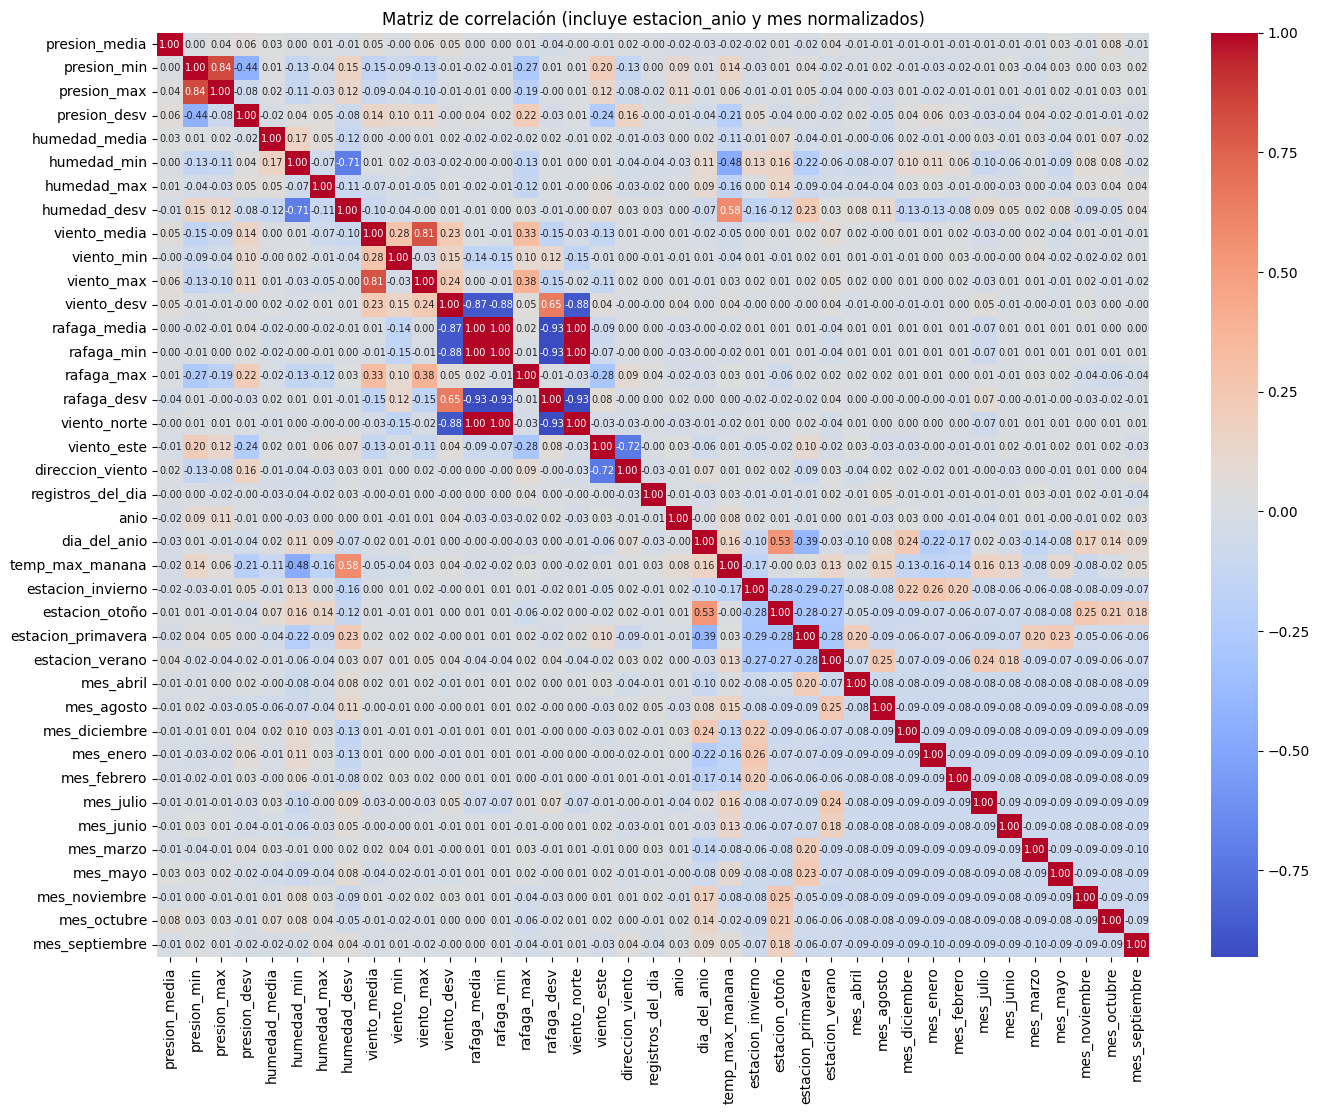

In [18]:
import seaborn as sns
import matplotlib.pyplot as plt

# Columnas numéricas originales (excluyendo fecha y sector_viento)
columnas_numericas = df.select_dtypes(include='number').columns.tolist()

# One-hot encoding de las categóricas normalizadas (sin sector_viento)
estacion_dummies = pd.get_dummies(df['estacion_anio'], prefix='estacion')
mes_dummies = pd.get_dummies(df['mes'], prefix='mes')

# Unir todo en un dataframe temporal solo para el análisis de correlación
df_corr = pd.concat([df[columnas_numericas], estacion_dummies, mes_dummies], axis=1)

# Matriz de correlación
plt.figure(figsize=(16,12))
sns.heatmap(df_corr.corr(), annot=True, cmap="coolwarm", fmt=".2f", annot_kws={"size":7})
plt.title("Matriz de correlación (incluye estacion_anio y mes normalizados)")
plt.show()

In [19]:
df.groupby('estacion_anio')['temp_max_manana'].mean()

estacion_anio
invierno     10.928582
otoño        13.804898
primavera    14.385639
verano       16.063740
Name: temp_max_manana, dtype: float64

A partir del mapa de calor como del promedio de temperatura por cada estación se puede ver claramente que no existe una correlación importante 

entre nuestra variable objetivo y la estación del año o el mes puesto a que se evidencia un resultado no mayor a 0.21, además aunque se puede 

evidenciar una variación en la temperatura con respecto a la estación esta no supera los 5 grados centigrados. Por lo tanto aunque es evidente 

una pequeña correlación, no se tendrán en cuenta estas variables para el modelo de regresión , puesto a que no representan una significancia lo 

suficientemente alta. 


Por otro lado, algo que pude evidenciar en este mapa de calor y que ignoré en el mapa anterior es que existe un problema de 

multicolienalidad entre las variables rafaga_media, rafaga_min y viento norte las cuales tienen  una correlación de 1.0 , lo que significa que si 

sabes el valor de una puedes automaticamente conocer el valor de la otra, por lo tanto son reduntantes entre si. Esto no representa un problema 

para el modelo debido a que se van a excluir debido a su baja correlación con la temperatura.

### Tratamiento de outliers.

De la exploración se pudo concluir que existen datos atípicos en la variable objetivo, los cuales no corresponden a la realidad y pueden afectar 

al modelo, por ende es necesario eliminarlos.

In [20]:
# Ver cuántas filas están afectadas
outliers_temp = df[df['temp_max_manana'] > 40]
print(f"Filas con temperatura objetivo > 40°C: {len(outliers_temp)}")
print(outliers_temp[['fecha', 'temp_max_manana']])

print("Filas antes:", df.shape[0])
df = df[df['temp_max_manana'] <= 40]
print("Filas después:", df.shape[0])

Filas con temperatura objetivo > 40°C: 5
          fecha  temp_max_manana
1335 2012-10-04           63.050
1374 2012-11-13           44.852
1525 2013-04-20           61.412
2105 2014-12-05           40.118
2136 2015-01-07           44.978
Filas antes: 2393
Filas después: 2388


### Busqueda de las variables predictoras

El siguiente paso es definir las variables predictoras que irán en el modelo de regresión lineal. Tras haber analizado el mapa de calor definí 

que las variables predictoras deben ser : humedad_desv, humedad_min, presion_dev, dia_del_anio. Esto en primer lugar debido a la fuerte 

correlación entre humedad_desv y temperatura con un valor de R^2 de 0.57 , sin embargo la variable sola unicamente explica el 32% de la variación 

de la temperatura , dejando un 68% sin explicar. Lo que puede ocasionar un RMSE alto y un modelo con baja capacidad predictiva real. Por lo tanto

la solución es buscar otras variables que tengan cierta correlación con el objetivo (aunque en menor medida) y aporten información distinta a la 
 
variable de humedad_desv. 


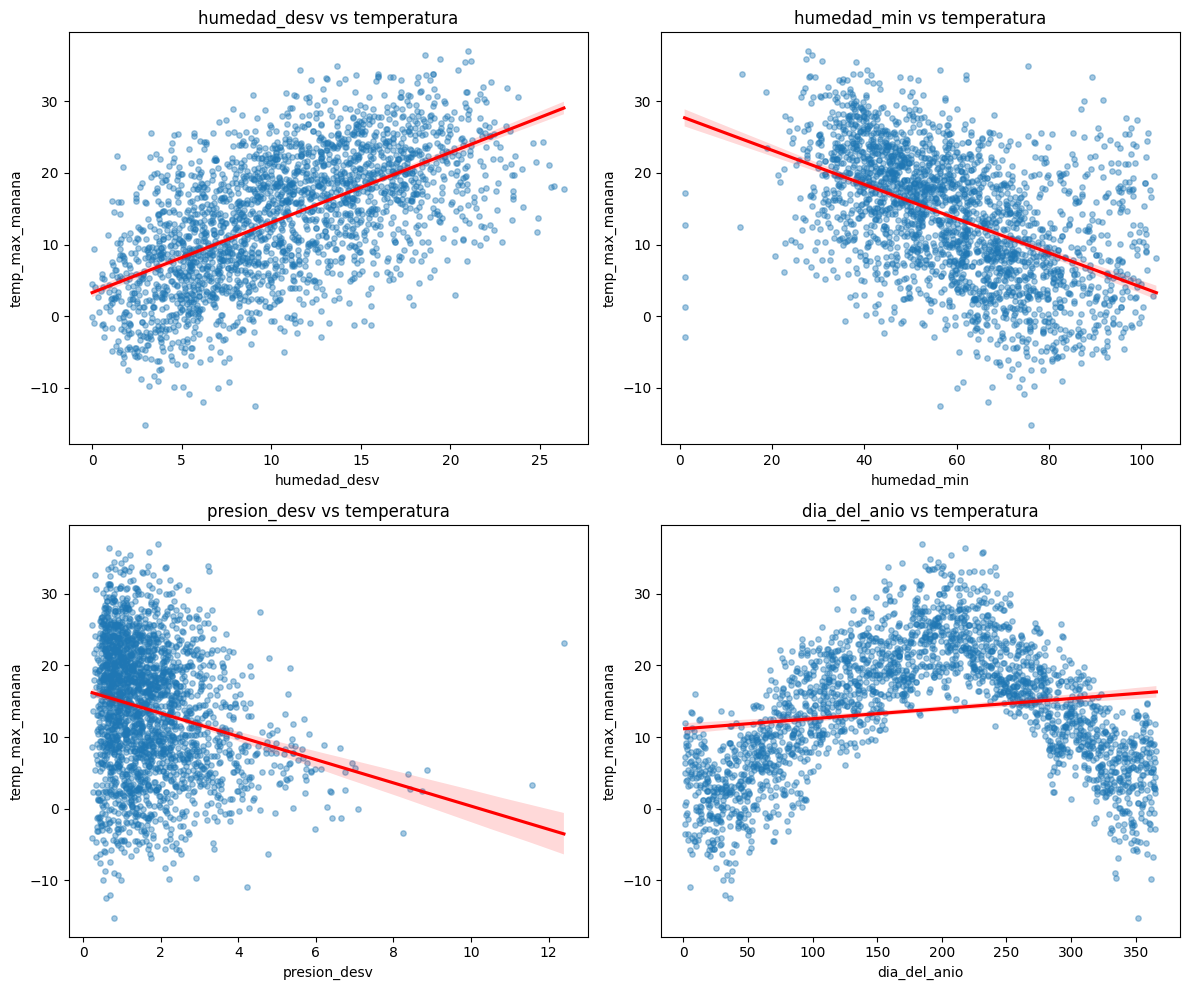

In [21]:

variables = ['humedad_desv', 'humedad_min', 'presion_desv', 'dia_del_anio']

fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes = axes.flatten()

for i, var in enumerate(variables):
    sns.regplot(x=df[var], y=df['temp_max_manana'], ax=axes[i], 
                scatter_kws={'alpha':0.4, 's':15}, line_kws={'color':'red'})
    axes[i].set_xlabel(var)
    axes[i].set_ylabel('temp_max_manana')
    axes[i].set_title(f'{var} vs temperatura')

plt.tight_layout()
plt.show()

De los scatterplots de las variables escogidas se puede evidenciar que tanto como la humedad_desv y humedad_min tienen correlación lineal con la 

variable objetivo. La variable de dia_del_anio mostró una relación no lineal de forma estacional (forma de U invertida), lo que es consistente 

con el ciclo climatico anual. Mientras que la presion_desv mostró un patrón de dispersión decreciente o de "cuña", que en realidad no arroja 

ninguna relación relevante con la temperattura y por ende será descartada.

### Transformación de la variable dia_del_anio

Para poder considerer a la variable dia_anio no basta con inputarla al modelo de regresión lineal tal como está debido a que no tiene una 

relación lineal como tal sino como una U invertida , lo que puede dar un coeficiente que no representa bien la realidad.  Esto se debe a

que dia_del_anio, en su escala original (1-365) representa su relación con la temperatura de manera ciclica y su codificación numerica posiciona

erroneamente fechas climaticas similares por ejemplo enero y diciembre. Por lo tanto es pertinente aplicar una transformación seno/coseno para 
 
representar el día del año en un espacio circular, corrigiendo ambos problemas simultaneamente.

dia_del_anio    0.164271
dia_sin        -0.209674
dia_cos        -0.811270
dtype: float64


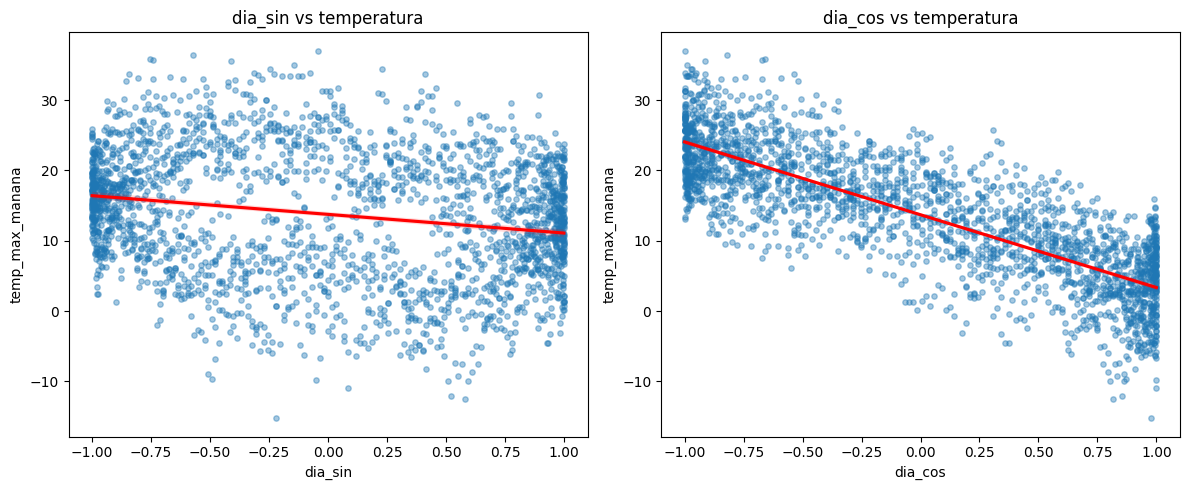

In [22]:
import numpy as np


# Transformación cíclica
df['dia_sin'] = np.sin(2 * np.pi * df['dia_del_anio'] / 365)
df['dia_cos'] = np.cos(2 * np.pi * df['dia_del_anio'] / 365)

# Verificar la nueva correlación
print(df[['dia_del_anio', 'dia_sin', 'dia_cos']].corrwith(df['temp_max_manana']))

# Visualizar
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
sns.regplot(x=df['dia_sin'], y=df['temp_max_manana'], ax=axes[0], scatter_kws={'alpha':0.4,'s':15}, line_kws={'color':'red'})
sns.regplot(x=df['dia_cos'], y=df['temp_max_manana'], ax=axes[1], scatter_kws={'alpha':0.4,'s':15}, line_kws={'color':'red'})
axes[0].set_title('dia_sin vs temperatura')
axes[1].set_title('dia_cos vs temperatura')
plt.tight_layout()
plt.show()

La transformación cíclica de dia_del_anio reveló una correlación fuerte con la temperatura (dia_cos = -0.81), muy superior a la variable original 

sin transformar confirmando que la relación estacional es de naturaleza circular.

### Resumen de la etapa de preparación


A partir de los hallazgos de la sección de exploración, se corrigieron problemas en las 4 dimensiones de calidad de datos. Asimsimo a través del

análisis de correlación se pudo evidenciar que las variables viento y rafaga asi como estacion_anio y mes , tienen una relación bastante débil 

con la temperatura objetivo, por lo que se excluyeron del modelo. Se identificó que dia_del_anio tiene una relación estacional no lineal con la 

temperatura , por lo que se optó a transformarla mediante componentes seno/conseno revelando una correlación fuerte (dia_cos = -0.81) que no era 

evidente en su escala original.

Tras estas correciones, el dataset final cuenta con 2,388 observaciones y las variables predictoras son: humedad_desv, humedad_min, dia_sin y 

dia_cos.

## Creación del Pipeline.

In [23]:


from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression

# Definir features (X) y objetivo (y)
features = ['humedad_desv', 'humedad_min', 'dia_sin', 'dia_cos']
X = df[features]
y = df['temp_max_manana']

# Train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42
)

print("Filas entrenamiento:", X_train.shape[0])
print("Filas prueba:", X_test.shape[0])

#  ColumnTransformer: escalado de las variables numéricas
preprocessor = ColumnTransformer(
    transformers=[
        ('escalado', StandardScaler(), features)
    ]
)

# Pipeline completo: preprocesamiento + modelo
modelo_1 = Pipeline(steps=[
    ('preprocesamiento', preprocessor),
    ('regresion', LinearRegression())
])

# Entrenar el pipeline
modelo_1.fit(X_train, y_train)

print("Pipeline entrenado correctamente")

Filas entrenamiento: 1791
Filas prueba: 597
Pipeline entrenado correctamente


Para la construcción del modelo se optó finalmente por definer como variables predictoras a humedad_desv, humedad_min, dia_sin y dia_cos. En primer lugar se dividió el conjunto 

de datos de entrenamiento y prueba utilizando train_test_split, con una proporción de 75%-25% (test_size = 0,25) y una semilla fila (random_seed= 42) para garantizar que la 

distribución no sea siempre la misma. El modelo se implentó mediante un PipeLine de scikit learn, que encadena dos etapas diferentes: primero, un ColumnTRansformar que aplica 

StandardScaler para estandarizar las variables predictoras, dandoles una media de 0 y desviación estándar de 1, y segundo el algoritmo LinearRegression. El proposito del 

pipeline es grantizar que el escalado se ajuste unicamente con los datos de entrenamiento evitando así el problema más grande de fuga de información, además  facilita que los 

coeficientes resultantes del modelo sean comparables entre sí al compartir la misma escala.

In [24]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np

y_pred = modelo_1.predict(X_test)

rmse = np.sqrt(mean_squared_error(y_test, y_pred))
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"RMSE: {rmse:.3f}")
print(f"MAE: {mae:.3f}")
print(f"R2: {r2:.3f}")

RMSE: 4.545
MAE: 3.636
R2: 0.731


El modelo obtuvo un RMSE de 4.54 grados, un MAE de 3.63 grados y un R^2 de 0.731 sobre el conjunto de prueba . El valor de R^2 lo que indica es que la variabilidad de la 

temperatura  máxima del día siguiente es explicada en un 73.1% por las cuatro variables seleccionadas un resultado considerablemente superior si en cambio se hubiera optado por 

utilizar unicamente la variable de humedad_desv. En cuanto al error, un RMSE de 4.54 grados representa una desviación promedio razonable considerando que la variable objetivo

abarca un rango de aproximadamente 55 grados, lo que equivale a un error del 8% dle rango total. La diferencia modertada entre RMSE y MAE suguiere que, si bien existen algunos 

errores de predicción más grandes que el promedio, estos no son extremos ni dominan el comportamiento general del modelo. Por lo tanto se puede decir que el modelo es una 

herramienta útil para una primera aproximación al riesgo climatico , por ejemplo para poder indentificar dias con temperatura elevada asociada a riesgos de incendio.

## Modelo 2: pipeline con imputación, escalado y codificación one-hot

A diferencia del Modelo 1 (variables numéricas seleccionadas por correlación, con interpolación temporal), este segundo modelo sigue la estructura vista en la práctica de Regresión Lineal (P41): un conjunto más amplio de variables (numéricas + categóricas), con imputación y escalado hechos **dentro del pipeline** de scikit-learn.

Esto tiene una ventaja metodológica sobre el Modelo 1: al imputar dentro del pipeline, el `SimpleImputer` solo aprende sus estadísticas del conjunto de entrenamiento (evitando la fuga de datos que implica interpolar sobre todo `df` antes de partirlo, como se hizo en el Modelo 1).

Este modelo parte de una copia independiente de los datos originales (`df2`), para no interferir con el `df` del Modelo 1.

In [25]:
df2 = pd.read_csv("Datos lab 1.csv")

# Mismos controles de calidad básicos que en el Modelo 1
df2 = df2.drop_duplicates()
df2 = df2.sort_values('fecha').drop_duplicates(subset='fecha', keep='first')
df2 = df2.dropna(subset=['fecha'])
df2 = df2.sort_values('fecha').reset_index(drop=True)
df2 = df2.dropna(subset=['temp_max_manana'])
df2['fecha'] = pd.to_datetime(df2['fecha'], format='%Y-%m-%d')
df2 = df2[df2['temp_max_manana'] <= 40]

print("Filas en df2:", df2.shape[0])
df2.head()

Filas en df2: 2388


,fecha,presion_media,presion_min,presion_max,presion_desv,humedad_media,humedad_min,humedad_max,humedad_desv,viento_media,...,viento_norte,viento_este,direccion_viento,registros_del_dia,anio,dia_del_anio,estacion_anio,mes,sector_viento,temp_max_manana
0,2009-01-01,999.1456,996.50,1000.87,1.3993,0.910860,0.875000,94.8,1.7650,0.7786,...,-0.3618,-0.0223,183.5308,143.0,2009.0,1.0,invierno,January,S,-2.12
1,2009-01-02,999.6006,997.93,1002.65,1.5039,0.920868,86.600000,96.3,2.7588,1.4195,...,0.4267,0.3689,40.8436,144.0,2009.0,2.0,invierno,JULY,NE,-0.82
2,2009-01-03,998.5486,993.05,1002.49,3.1304,76.458100,48.390000,93.9,15.1796,1.2509,...,-0.6993,-0.5268,216.9916,144.0,2009.0,3.0,invierno,January,SO,-0.63
3,2009-01-04,988.5107,985.12,992.93,2.3223,89.417400,97.946704,NaN,4.4904,1.7204,...,-1.1268,-1.0413,222.7419,144.0,2009.0,4.0,invierno,JANUARY,SO,-1.44
4,2009-01-05,990.4057,NaN,997.54,4.2315,86.260400,74.600000,93.2,5.3922,3.8003,...,2.6275,0.2874,6.2418,NaN,2009.0,5.0,East,January,N,-10.88


### Validez de las variables predictoras

Se detectaron valores físicamente imposibles en varias columnas numéricas (presión de 9939 mbar, ráfagas negativas o con centinela -9999, etc.) que no fueron corregidos en la etapa de preparación del Modelo 1 porque ese modelo no usa esas variables. Aquí sí las necesitamos, así que se convierten a `NaN` los valores fuera de rango físico, y se dejan para que el `SimpleImputer` del pipeline los rellene más adelante (usando solo estadísticas del conjunto de entrenamiento).

In [26]:
rangos_validos = {
    'presion_media': (850, 1100), 'presion_min': (850, 1100), 'presion_max': (850, 1100),
    'humedad_media': (0, 100), 'humedad_min': (0, 100), 'humedad_max': (0, 100),
    'viento_media': (0, 60), 'viento_min': (0, 60), 'viento_max': (0, 60), 'viento_desv': (0, 30),
    'rafaga_media': (0, 60), 'rafaga_min': (0, 60), 'rafaga_max': (0, 60), 'rafaga_desv': (0, 30),
    'viento_norte': (-30, 30), 'viento_este': (-30, 30), 'direccion_viento': (0, 360),
}

for col, (lo, hi) in rangos_validos.items():
    df2.loc[(df2[col] < lo) | (df2[col] > hi), col] = np.nan

df2[list(rangos_validos.keys())].describe().T[['min', 'max']]

,min,max
presion_media,948.996000,1011.653800
presion_min,913.600000,1012.320198
presion_max,951.940000,1013.940000
humedad_media,0.004663,100.000000
humedad_min,0.237700,100.000000
humedad_max,27.020000,100.000000
viento_media,0.000000,24.428880
viento_min,0.000000,45.184956
viento_max,0.000000,45.108000
viento_desv,0.000000,24.880000


### Normalización de categóricas

Se reutilizan los mismos diccionarios de mapeo (`mapa_mes`, `mapa_viento`) ya definidos para el Modelo 1, para no duplicar esa lógica.

In [27]:
for col in ['mes', 'sector_viento']:
    df2[col] = df2[col].str.strip().str.lower()

df2['mes'] = df2['mes'].map(mapa_mes)
df2['sector_viento'] = df2['sector_viento'].map(mapa_viento)

for col in ['mes', 'sector_viento']:
    print(f"\n{col}: {df2[col].nunique()} categorías, {df2[col].isnull().sum()} nulos")


mes: 12 categorías, 86 nulos

sector_viento: 8 categorías, 64 nulos


### Definición de variables y partición entrenamiento/prueba

Se excluyen como predictoras: `fecha` (no es un predictor directo), `estacion_anio` (se usa `mes` en su lugar, con más granularidad), `dia_del_anio` (redundante una vez que `mes` representa la estacionalidad) y `registros_del_dia` (es un metadato de calidad de la medición, no una variable meteorológica).

Se usa el mismo `random_state=42` y `test_size=0.25` que en el Modelo 1 — y como `df2` tiene las mismas filas en el mismo orden que `df`, la partición debería caer sobre las mismas fechas, haciendo la comparación entre modelos más justa.

In [28]:
columnas_excluidas = ['fecha', 'temp_max_manana', 'estacion_anio', 'dia_del_anio', 'registros_del_dia']

X2 = df2.drop(columns=columnas_excluidas)
y2 = df2['temp_max_manana']

X_train2, X_test2, y_train2, y_test2 = train_test_split(
    X2, y2, test_size=0.25, random_state=42
)

print("Entrenamiento:", X_train2.shape)
print("Prueba interna:", X_test2.shape)

Entrenamiento: (1791, 22)
Prueba interna: (597, 22)


### Pipeline de preprocesamiento

Se definen dos sub-pipelines, uno para numéricas y otro para categóricas, y se combinan con `ColumnTransformer` (mismo patrón de P41).

Se usa `drop="first"` en el `OneHotEncoder` en vez de `drop="if_binary"` (como en P41): con `mes` (12 categorías) y `sector_viento` (8 categorías), `if_binary` no elimina ninguna columna dummy (ninguna de las dos es binaria), lo que dejaría el modelo con la trampa de la variable dummy (columnas perfectamente colineales con el intercepto) y un VIF infinito al momento de verificar supuestos más adelante.

In [29]:
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder

numeric_features = [
    'presion_media', 'presion_min', 'presion_max', 'presion_desv',
    'humedad_media', 'humedad_min', 'humedad_max', 'humedad_desv',
    'viento_media', 'viento_min', 'viento_max', 'viento_desv',
    'rafaga_media', 'rafaga_min', 'rafaga_max', 'rafaga_desv',
    'viento_norte', 'viento_este', 'direccion_viento',
    'anio'
]
categorical_features = ['mes', 'sector_viento']

numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="mean")),
    ("scaler", StandardScaler()),
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore", drop="first")),
])

preprocessor2 = ColumnTransformer(transformers=[
    ("num", numeric_transformer, numeric_features),
    ("cat", categorical_transformer, categorical_features),
])

### Entrenamiento del Modelo 2

In [30]:
modelo_2 = Pipeline(steps=[
    ("preprocesamiento", preprocessor2),
    ("regresion", LinearRegression())
])

modelo_2.fit(X_train2, y_train2)

print("Modelo 2 entrenado correctamente")

Modelo 2 entrenado correctamente


### Evaluación del Modelo 2

In [31]:
y_pred2 = modelo_2.predict(X_test2)

rmse2 = np.sqrt(mean_squared_error(y_test2, y_pred2))
mae2 = mean_absolute_error(y_test2, y_pred2)
r2_2 = r2_score(y_test2, y_pred2)

print(f"RMSE: {rmse2:.3f}")
print(f"MAE: {mae2:.3f}")
print(f"R2: {r2_2:.3f}")

RMSE: 6.521
MAE: 5.161
R2: 0.446


### Predicho vs. real — Modelo 2

Visualización rápida de qué tan cerca están las predicciones del Modelo 2 de los valores reales sobre el conjunto de prueba interno.

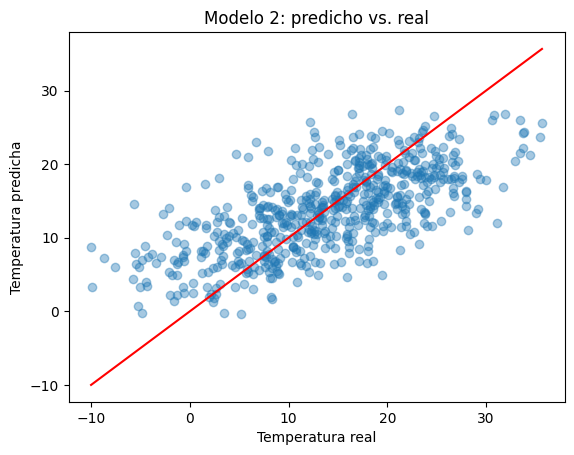

In [32]:
plt.scatter(y_test2, y_pred2, alpha=0.4)
plt.plot([y_test2.min(), y_test2.max()], [y_test2.min(), y_test2.max()], color='red')
plt.xlabel('Temperatura real')
plt.ylabel('Temperatura predicha')
plt.title('Modelo 2: predicho vs. real')
plt.show()

### Verificación: ¿ambos modelos se evalúan sobre las mismas observaciones?

Antes de comparar métricas, se verifica que `X_test` (Modelo 1) y `X_test2` (Modelo 2) correspondan exactamente a las mismas filas — necesario para que la comparación sea justa, ya que ambos splits usan `random_state=42` pero parten de `df` y `df2`, dos copias procesadas por separado.

In [33]:
mismas_filas = set(X_test.index) == set(X_test2.index)
print(f"¿Modelo 1 y Modelo 2 se evalúan sobre las mismas {len(X_test)} observaciones? {mismas_filas}")

¿Modelo 1 y Modelo 2 se evalúan sobre las mismas 597 observaciones? True


### Tabla comparativa: Modelo 1 vs. Modelo 2

Comparación de los dos modelos sobre sus respectivos conjuntos de prueba interna (verificados como las mismas observaciones).

In [34]:
tabla_comparativa = pd.DataFrame({
    'Modelo 1 (selección manual + interpolación)': {'RMSE': rmse, 'MAE': mae, 'R2': r2},
    'Modelo 2 (imputación + escalado + one-hot)': {'RMSE': rmse2, 'MAE': mae2, 'R2': r2_2},
}).T

tabla_comparativa

,RMSE,MAE,R2
Modelo 1 (selección manual + interpolación),4.544819,3.636443,0.731027
Modelo 2 (imputación + escalado + one-hot),6.520758,5.161166,0.446304


**Interpretación:** el Modelo 2 obtuvo un desempeño notablemente inferior al Modelo 1 (R² más bajo, RMSE y MAE más altos). Esto sugiere, aunque no se comprobó de forma aislada, que la combinación de un conjunto amplio de variables correlacionadas entre sí con una imputación estadística genérica pudo afectar la generalización del modelo, en contraste con la selección reducida y guiada por correlación del Modelo 1. Confirmar esta hipótesis requeriría aislar cada factor por separado (por ejemplo, entrenar con las mismas 19 variables pero sin colinealidad, o con la misma imputación pero con variables reducidas).

Con base en esta tabla, el **Modelo 1** es el modelo seleccionado para las siguientes etapas (importancia de variables, verificación de supuestos y generación de predicciones finales).

## Importancia de variables — Modelo 1 (modelo seleccionado)

Como las 4 variables predictoras están estandarizadas (`StandardScaler`), el valor del coeficiente de cada una es directamente comparable entre sí: indica cuántos grados centígrados cambia la predicción de `temp_max_manana` por cada desviación estándar de cambio en esa variable, manteniendo las demás constantes.

In [35]:
nombres_features = preprocessor.get_feature_names_out()
nombres_features = [n.replace('escalado__', '') for n in nombres_features]

coeficientes = modelo_1.named_steps['regresion'].coef_
intercepto = modelo_1.named_steps['regresion'].intercept_

tabla_importancia = pd.DataFrame({
    'variable': nombres_features,
    'coeficiente': coeficientes
})
tabla_importancia['coeficiente_abs'] = tabla_importancia['coeficiente'].abs()
tabla_importancia = tabla_importancia.sort_values('coeficiente_abs', ascending=False).reset_index(drop=True)

print(f"Intercepto: {intercepto:.4f}")
tabla_importancia

Intercepto: 13.7198


,variable,coeficiente,coeficiente_abs
0,dia_cos,-6.076742,6.076742
1,dia_sin,-2.023505,2.023505
2,humedad_desv,1.756026,1.756026
3,humedad_min,-0.778894,0.778894


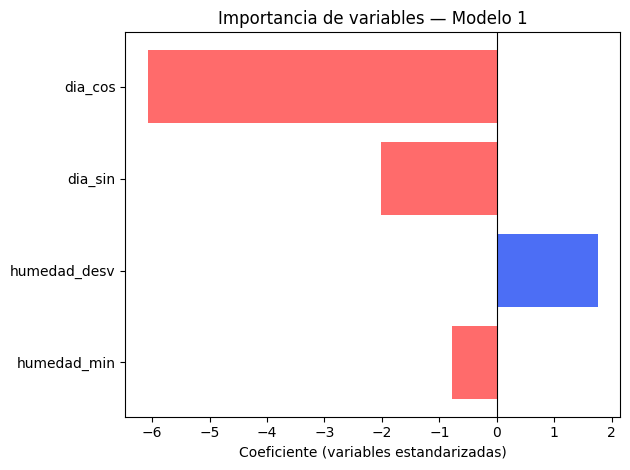

In [36]:
colores = ['#4C6EF5' if c > 0 else '#FF6B6B' for c in tabla_importancia['coeficiente']]
plt.barh(tabla_importancia['variable'], tabla_importancia['coeficiente'], color=colores)
plt.axvline(0, color='black', linewidth=0.8)
plt.xlabel('Coeficiente (variables estandarizadas)')
plt.title('Importancia de variables — Modelo 1')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

## Validar los supuestos de regresión lineal del modelo 1.

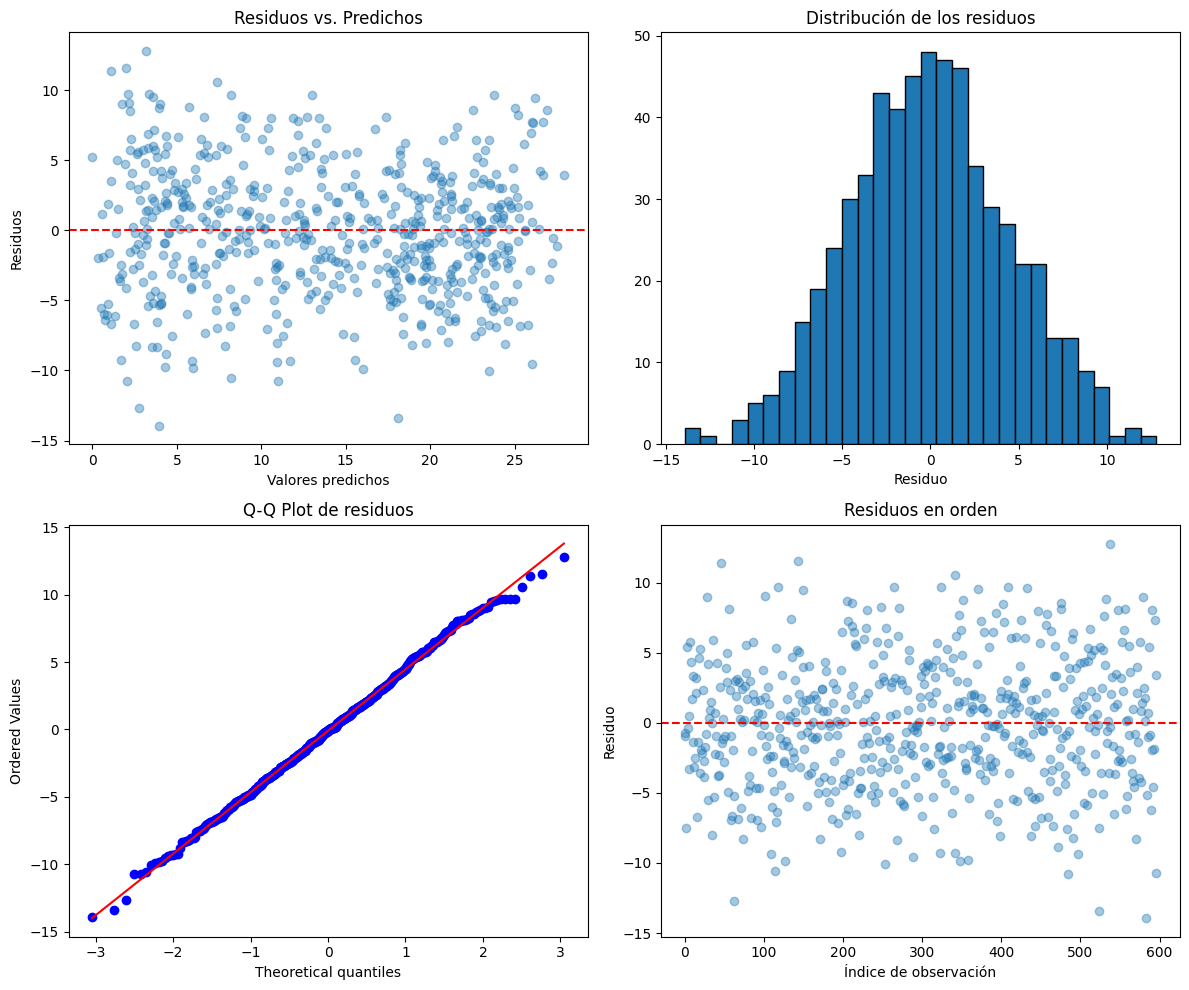

Test de Shapiro-Wilk: estadístico=0.9982, p-valor=0.8144


In [37]:
import scipy.stats as stats

residuos = y_test - y_pred

fig, axes = plt.subplots(2, 2, figsize=(12, 10))

#  residuos vs. predichos
axes[0,0].scatter(y_pred, residuos, alpha=0.4)
axes[0,0].axhline(0, color='red', linestyle='--')
axes[0,0].set_xlabel('Valores predichos')
axes[0,0].set_ylabel('Residuos')
axes[0,0].set_title('Residuos vs. Predichos')

# histograma de residuos
axes[0,1].hist(residuos, bins=30, edgecolor='black')
axes[0,1].set_title('Distribución de los residuos')
axes[0,1].set_xlabel('Residuo')

#   Q-Q plot
stats.probplot(residuos, dist="norm", plot=axes[1,0])
axes[1,0].set_title('Q-Q Plot de residuos')

#  residuos en orden (usando el índice como proxy de orden temporal)
axes[1,1].scatter(range(len(residuos)), residuos, alpha=0.4)
axes[1,1].axhline(0, color='red', linestyle='--')
axes[1,1].set_xlabel('Índice de observación')
axes[1,1].set_ylabel('Residuo')
axes[1,1].set_title('Residuos en orden')

plt.tight_layout()
plt.show()

# Prueba estadística de normalidad (complementa el Q-Q plot visual)
shapiro_stat, shapiro_p = stats.shapiro(residuos)
print(f"Test de Shapiro-Wilk: estadístico={shapiro_stat:.4f}, p-valor={shapiro_p:.4f}")

El proposito del codigo anterior es calcular y analizar el comportamiento de los residuos: la siferencia entre la temperatura   (y_test) y el valor que predijo el modelo 

(y_pred) para cada observación del conjunto de prueba. Un residiuo positivo significa que el modelo subestimó la temperatura real; uno negativo que la sobreestimó.


En el gráfico 1 sirve para evaluar la linealidad del modelo, es decir si captura bien la relación en todo el rango de predicción o falla en algún tramo, y de igual forma evalua 

homocedasticidad , es decir si mantiene el tamaño de error sin importar si la predicción es alta o baja. Según los resultados de la gráfica los residuos se distribuyen de forma 

dispersa y sin un patrón curvo evidente, tanto para predicciones altas como bajas . Esto puede indicar una homocedasticidad razonable ya que  la dispersión vertical se mantiene 

constante a lo largo del eje  X.

El gráfico 2 (Histograma de residuos) cuanta cúantos residuos caen en cada rango de valores , mostrando su distribución.En este caso se busca evaluar la normalidad . Según los 

resultados eñl histograma muestra una forma acampanada, simetrica , centrada en cero , lo que la asemeja a una distribución normal. Lo cual es una señal bastante favorable para 

el supuesto de normalidad de residuos.



El gráfico 3 es una prueba más rigurosa del supuesto de normalidad, al comparar los cuantiles de los residuos reales (eje Y), contra los cuantiles que tendría una distribución 

normal teórica perfecta. Según los resultados los puntos siguen la linea diagonal de forma muy cercana en la parte central de la distribución. Aunque se observa una leve 

desviación en ambas colas , esto indica que los resultados tienen colas un poco más pesadas que una normal perfecta.


El gráfico 4 dibuja cada residuo según su índice en el conjunto de dato, para revisar si existe algún patrón a lo largo de las observaciones. Según los resultados, los residuos

 se distribuyen de manera aleatoria alrededor de cero sin ningún patrón visisble . Lo que suguiere que el supuesto de independencia se cumple adecuadamente.

## Generación de predicciones.


In [38]:
# 1. Cargar el archivo de test (sin etiquetas)
df_test = pd.read_csv("Datos Test Lab 1.csv")
print("Filas en el archivo de test:", df_test.shape[0])
df_test.head()

#  Aplicar las MISMAS transformaciones de preparación que se usaron en el Modelo 1
#    (mismo orden y misma lógica, pero SIN eliminar filas por nulos/outliers,
#     porque aquí necesitas predecir sobre TODAS las filas del archivo de test)

# Corrección de escala en humedad_min (fracción -> porcentaje)
mask_min_test = df_test['humedad_min'] < 1
df_test.loc[mask_min_test, 'humedad_min'] = df_test.loc[mask_min_test, 'humedad_min'] * 100

# Transformación cíclica de dia_del_anio
df_test['dia_sin'] = np.sin(2 * np.pi * df_test['dia_del_anio'] / 365)
df_test['dia_cos'] = np.cos(2 * np.pi * df_test['dia_del_anio'] / 365)

# Verificar que no queden nulos en las columnas que el modelo necesita
features = ['humedad_desv', 'humedad_min', 'dia_sin', 'dia_cos']
print(df_test[features].isnull().sum())


#  Si aparecen nulos en las columnas predictoras, imputar (no eliminar filas,
#    porque cada fila del test debe tener una predicción en el CSV final)
for col in features:
    if df_test[col].isnull().sum() > 0:
        df_test[col] = df_test[col].fillna(df_test[col].median())
        
        
#  Generar las predicciones con el pipeline ya entrenado (modelo_1)
X_test_final = df_test[features]
predicciones = modelo_1.predict(X_test_final)

df_test['temp_max_manana_predicha'] = predicciones
df_test[['fecha', 'temp_max_manana_predicha']].head()

#  Exportar el CSV final, tomando como base el archivo original de test
df_resultado = pd.read_csv("Datos Test Lab 1.csv")  # se recarga el original intacto
df_resultado['temp_max_manana'] = predicciones      # se agrega la columna de predicción

df_resultado.to_csv("Datos Test Lab1.csv", index=False)
print("Archivo exportado correctamente")

Filas en el archivo de test: 364
humedad_desv    0
humedad_min     0
dia_sin         0
dia_cos         0
dtype: int64
Archivo exportado correctamente


## Análisis de resultados


### ¿Cual fue el valor de los diferentes coeficientes obtenidos ?


In [39]:
nombres_features = preprocessor.get_feature_names_out()
nombres_features = [n.replace('escalado__', '') for n in nombres_features]

coeficientes = modelo_1.named_steps['regresion'].coef_
intercepto = modelo_1.named_steps['regresion'].intercept_

print(f"Intercepto: {intercepto:.4f}")
for nombre, coef in zip(nombres_features, coeficientes):
    print(f"{nombre}: {coef:.4f}")

Intercepto: 13.7198
humedad_desv: 1.7560
humedad_min: -0.7789
dia_sin: -2.0235
dia_cos: -6.0767


Al estar todas estas variables estandarizadas , estos valores son directamente comparables emtre sí, y se puede concluir que dia_cos es, por 

margen amplio, la variable con mayor peso en la predicción.

### ¿ Cual modelo ofrece el mejor rendimiento sobre el test?¿ Que interpretación puedes dar?

De la tabla comparativa es evidente que el modelo 1 superó al modelo 2  en las tres métricas puesto a que tiene un menor RMSE, un menor MAE y 

mayor R^2. Esto me indica que, para este problema, un conjunto reducidoy cuidadosamente seleccionado de variables generaliza mejor que un 

conjunto amplio con variables redundantes e imputación menos informada del contexto temporal. 

### ¿ Cuales variables fueron seleccionadas ? ¿ Que interpretación de negocio se puede dar?


Las variables finalmente selccionadas fueron humedad_desv, humedad_min, dia_sin y dia_cos . La dominancia de los componentes ciclicos del día del 

año (dia_cos con coeficiente -6.08) confirma que la estación en la que se encuentra en el momento es el factor más determinante para predecir la 

temperatura máxima del día siguiente. Por otro lado el coeficiente de humedad_desv (+1.76) suguiere que días con mayor variabilidad de humedad 

tienden a asociarse con temperaturas más altas al día siguiente. Para AlpesPlanck, esto iumplica que un sistema de alerta temprana de riesgo 

climatico podría priorizar el monitoreo de la variabilidad diaria de humedad, adempas del calendario estacional, con señales tempranas de días de

 mayor riesgo por altas temperaturas.

### ¿ Como representar la regresión lineal de forma mtemática ? Metodo y proceso

El modelo se representa como 

humedad_max_manana = B0 + B1(humedad_desv) + B2(humedad_min) + B3(dia_sin) + B4(dia_cos) + e

Donde B0 es el intercepto, B1 a B4 son los coeficientes asociados a cada variable estandarizada y e es el terminop de error aleatorio. El método

utilizado para resolver este sistema y encontrar los valores optimos de B fue minimos cuadrados ordinarios, el cual está implementado 

internamente por LinearRegression() de sckit-learn. Este método busca los coeficientes que minimizan la suma de los residuos al cuadrado (la 

diferencia entre el valor real y el predicho, elevada al cuadrado) sobre el conjunto de entrenamiento , resolviendo el problema mediante álgebra 

matricial.

### ¿ Que tipo de sesgos podría afectar los resultados ? Describe dos tipos.


Uno de los sesgos identificados fue el sesgo de medición ya que durante la exploración se identificaron múltiples errores en la captura de datos 

por ejemplo los valores de -9999 en variables de viento, el error de escala de humedad_min y humedad_media (fracción vs porcentaje) y valores

fisicamente imposibles en presion_media y temp_max_manana. Si estos errores no se hubieran detectado y corregido, habrían introducido ruido que 
 
distorciona las relaciones reales entre variables.


Otro sesgo identificado fue el de selcción temporal/ geográfica ya que el dataset proviene exclusivamente de una estacion meteorologica en Jena, 

Alemania. Durante un periodo de tiempo muy concreto . El modelo entrenado captura patrones climaticos particulares de esa región y época; 

aplicarlo en diferentes contextos producirá predicciones poco confiables.

## Uso de herramientas de IA generativa.

Declaración de uso: Se utilizó Claude (Anthropic) como apoyo conceptual, generación de código y depuración durante las etapas de exploración , 

preparación , modelado y análisis de resultados.

### Prompts utilizados:

"Este es mi avance, que cosas debo complementar, cambiar, corregir y cual debe ser mi siguiente paso a seguir inmediato"

"Puedes darme el código que me revise la validez de las columnas tipo texto"


"Ahora que están normalizados quiero verificar la correlación con la variable objetivo, dame el código para el mapa de calor"

"Por qué debo modificar la variable dia_anio antes de poder usarla en el modelo"


"Avancemos con la construcción del pipeline"


"Ayúdame con la generación de predicciones sobre datos test lab 1"


### ¿Qué partes fueron correctas y útiles? 

El código de limpieza (nulos, duplicados, normalización de texto) y la construcción del pipeline con 

ColumnTransformer funcionaron correctamente y siguieron buenas prácticas de scikit-learn.


### ¿Qué decisiones técnicas fueron modificadas? 

Se validó cada sugerencia contra los datos reales antes de aplicarla por ejemplo, se verificó 

manualmente que el error de escala en humedad_min fuera real antes de corregirlo, y se comprobó que ambos modelos se evaluaran sobre las mismas 

observaciones antes de comparar sus métricas.


### Aportes propios del estudiante:

Identifiqué de manera inicial los problemas de valores atípicos (-9999 en viento, -15230 en fechas repetidas, patrón de ceros en humedad_min) a 

partir de la exploración propia de los datos.


Realicé las desiciones finales acerca de las variables  que se van o no incluir en la elaboración del modelo y justifique la selección del modelo 

1 como modelo final. Ejecución, verificación y validación de todo el código en el entorno propio, incluyendo la interpretación de los gráficos de supuestos de 

regresión.



